# [Baseline] RandomForest — 풍력발전량 예측

기상 예보 데이터(LDAPS/GFS)로 KPX 발전그룹 3곳의 시간대별 **풍력발전량(kWh)** 을 예측하는 회귀 베이스라인입니다.

- **입력**: 예측 시각별 LDAPS/GFS 기상 예보 격자 평균값 + 시간·요일·계절성 캘린더 변수
- **출력**: `kpx_group_1/2/3` 세 발전그룹의 시간대별 예측 발전량(kWh)
- **모델**: 그룹별 `RandomForestRegressor` (Label 제공 기간이 그룹마다 다르므로 각각 따로 학습)

이 대회는 예측 결과 CSV(`baseline_submit.csv`)를 제출하는 방식이라, 데이터 로드부터 제출 파일 생성까지
이 노트북 하나로 처리합니다.


## 1. 라이브러리 불러오기

데이터 처리(pandas, numpy)와 회귀 모델 학습(scikit-learn)에 필요한 라이브러리를 불러옵니다.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer


## 2. 데이터 로드

발전량 Label(`train_labels.csv`), 제출 양식(`sample_submission.csv`), LDAPS/GFS 기상 예보 데이터를 불러오고,
날짜 컬럼을 datetime으로 변환합니다. `CAPACITY_KWH` 는 그룹별 설비 용량으로, 이후 예측값을 클리핑하는 데
사용합니다.


In [2]:
DATA_DIR = Path(r"C:\Users\user\iCloudDrive\riversun\동국대학교\3학년 1학기\대외활동\DACON\데이터\open")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

TARGET_COLS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
CAPACITY_KWH = {
    "kpx_group_1": 21600,
    "kpx_group_2": 21600,
    "kpx_group_3": 21000,
}

train_labels = pd.read_csv(TRAIN_DIR / "train_labels.csv", encoding="utf-8-sig")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig")

ldaps_train = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(TRAIN_DIR / "gfs_train.csv", encoding="utf-8-sig")
ldaps_test = pd.read_csv(TEST_DIR / "ldaps_test.csv", encoding="utf-8-sig")
gfs_test = pd.read_csv(TEST_DIR / "gfs_test.csv", encoding="utf-8-sig")

train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])
sample_submission["forecast_kst_dtm"] = pd.to_datetime(sample_submission["forecast_kst_dtm"])

scada_vestas = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv", encoding="utf-8-sig")
scada_unison = pd.read_csv(TRAIN_DIR / "scada_unison_train.csv", encoding="utf-8-sig")

print("train_labels:", train_labels.shape)
print("sample_submission:", sample_submission.shape)
print("ldaps_train:", ldaps_train.shape, "gfs_train:", gfs_train.shape)
print("ldaps_test:", ldaps_test.shape, "gfs_test:", gfs_test.shape)


train_labels: (26304, 4)
sample_submission: (8760, 5)
ldaps_train: (420864, 35) gfs_train: (236736, 40)
ldaps_test: (140160, 35) gfs_test: (78840, 40)


## 3. 데이터 전처리
P1. SCADA 글리치 제거

P2. Group 3 라벨 결측 처리

P3. NWP U/V → 풍속/풍향 변환

P4. Grid 선택

P5. NWP 풍속 Bias Correction

P6. Downtime 구간 플래깅

P7. Temporal Feature Engineering

P8. data_available_kst_dtm 활용 (leakage 방지)

P9. 10% 제외 규칙을 학습에 반영

P10. Train/Validation Split

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# =====================================================================
# 1. [P10] 시간 컬럼 datetime 변환 및 통합 관리
# =====================================================================
for df in [train_labels, scada_vestas, scada_unison, ldaps_train, gfs_train]:
    time_col = [col for col in df.columns if 'dtm' in col or 'time' in col][0]
    df[time_col] = pd.to_datetime(df[time_col])


# =====================================================================
# 2. [P8] 데이터 누수(Leakage) 방지: NWP 중복 제거 및 가용성 필터링
# =====================================================================
def clean_nwp(df):
    df = df[df['data_available_kst_dtm'] <= df['forecast_kst_dtm']]
    df = df.sort_values(by=['forecast_kst_dtm', 'data_available_kst_dtm'])
    df = df.drop_duplicates(subset=['forecast_kst_dtm', 'grid_id'], keep='last')
    return df

print("Cleaning NWP data...")
ldaps_train = clean_nwp(ldaps_train)
gfs_train = clean_nwp(gfs_train)


# =====================================================================
# 3. [P3 & P4] NWP 격자 선택, 물리 변수 변환 및 비선형 피처 생성
# =====================================================================
def process_nwp_features(df, prefix='ldaps'):
    if prefix == 'ldaps':
        u_col = 'heightAboveGround_10_10u'
        v_col = 'heightAboveGround_10_10v'
        t_col = 'heightAboveGround_2_t'       
        p_col = 'surface_0_sp'                
        h_col = 'heightAboveGround_2_r'       
    else:  
        u_col = 'heightAboveGround_10_10u'
        v_col = 'heightAboveGround_10_10v'
        t_col = 'heightAboveGround_2_2t'      
        p_col = 'surface_0_sp'                
        h_col = 'heightAboveGround_2_2r'      
    
    # 🎯 [신규 추가] 명세서 기반 기상 데이터 이상치 및 노이즈 실시간 타격 청소
    # 1. 모든 복사 에너지 변수의 밤 시간대 음수 노이즈 -> 0으로 클리핑
    rad_cols = [col for col in df.columns if any(r in col for r in ['dswrf', 'NDNSW', 'SWDIR', 'SWDIF'])]
    for col in rad_cols:
        if col in df.columns:
            df[col] = np.where(df[col] < 0, 0, df[col])
        
    # 2. 모든 풍속/돌풍(Gust)/경계층 바람 변수의 비현실적 상한선 -> 35m/s로 컷오프
    wind_related_cols = [
        col for col in df.columns
        if any(w in col for w in ['_10u', '_10v', '_u', '_v', 'gust', 'BLWS']) # 🎯 오인 방지를 위해 언더바(_) 추가
        and 'dtm' not in col and 'id' not in col # 🎯 문자열 시간/ID 컬럼 방어
    ]
    for col in wind_related_cols:
        if col in df.columns:
            df[col] = np.clip(df[col], -35.0, 35.0)

    temp_c = df[t_col] - 273.15  
    temp_k = df[t_col]
    press_hpa = df[p_col] / 100.0  
    
    # ① 대기밀도
    e_s = 6.1078 * 10 ** ((7.5 * temp_c) / (temp_c + 237.3))
    e = (df[h_col] / 100.0) * e_s
    p_dry = press_hpa - e
    df['air_density'] = (p_dry / (287.058 * temp_k)) + ((e / (461.495 * temp_k)))
    
    # ② 절대습도
    alpha = ((17.27 * temp_c) / (237.7 + temp_c)) + np.log(0.5)
    dew_point = (237.7 * alpha) / (17.27 - alpha)
    e_s_dew = 6.112 * np.exp((17.67 * dew_point) / (dew_point + 243.5))
    e_a = e_s_dew * (df[h_col] / 100.0)
    e_a_Pa = e_a * 100.0
    rho_d = (press_hpa * 100.0) / (287.058 * temp_k)
    rho_v = (e_a_Pa / (461.495 * temp_k))
    df['absolute_humidity'] = (rho_v / (rho_d + rho_v)) * 1000.0
    
    # ③ 공기분압
    e_s_air = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    e_air = e_s_air * (df[h_col] / 100.0)
    rho_d_air = (press_hpa * 100.0) / (287.058 * temp_k)
    rho_v_air = (e_air * 100.0) / (461.495 * temp_k)
    df['air_pressure'] = (rho_d_air + rho_v_air) * 287.058 * temp_k / 100.0

    df['ws'] = np.sqrt(df[u_col]**2 + df[v_col]**2)
    df['wd'] = np.arctan2(-df[u_col], -df[v_col])
    df['ws_sin'] = df['ws'] * np.sin(df['wd'])
    df['ws_cos'] = df['ws'] * np.cos(df['wd'])

    df['ws_squared'] = df['ws'] ** 2
    df['ws_cubed'] = df['ws'] ** 3
    
    grouped = df.groupby('forecast_kst_dtm').agg({
        'ws': ['mean', 'max', 'std'],
        'ws_squared': ['mean', 'max'],
        'ws_cubed': ['mean', 'max'],
        'ws_sin': 'mean',
        'ws_cos': 'mean',
        'air_density': 'mean',       
        'absolute_humidity': 'mean', 
        'air_pressure': 'mean'       
    })
    
    grouped.columns = [f"{prefix}_{c[0]}_{c[1]}" for c in grouped.columns]
    res_df = grouped.reset_index()
    res_df['forecast_kst_dtm'] = pd.to_datetime(res_df['forecast_kst_dtm'])
    return res_df

print("Extracting NWP features...")
ldaps_features = process_nwp_features(ldaps_train, prefix='ldaps')
gfs_features = process_nwp_features(gfs_train, prefix='gfs')


# =====================================================================
# 4. [P1 & P6] 🌟 모든 Vestas 터빈(wtg01 ~ wtg12) 일괄 전처리 🌟
# =====================================================================
print("Processing SCADA glitches for all Vestas WTGs...")
vestas_cap = 780
vestas_all_wtgs = [f'wtg{i:02d}' for i in range(1, 13)]

scada_vestas['hourly_kst'] = scada_vestas['kst_dtm'].dt.floor('h')

# 각 시간대별로 모든 터빈의 다운타임 발생 횟수와 유효 터빈 수를 카운트할 변수 초기화
scada_vestas['total_downtime_count'] = 0
scada_vestas['active_turbine_count'] = 0

for wtg in vestas_all_wtgs:
    power_col = f'vestas_{wtg}_power_kw10m'
    ws_col = f'vestas_{wtg}_ws'
    
    # 1) P1. 각 터빈의 물리 상한 초과 글리치 이상치 제거
    scada_vestas[power_col] = np.where(
        scada_vestas[power_col] > vestas_cap * 1.3, 
        np.nan, 
        scada_vestas[power_col]
    )
    # 🎯 [딱 이 한 줄만 추가!] 수백만 단위의 거대 음수 및 대기전력 마이너스 노이즈를 0으로 차단
    scada_vestas[power_col] = np.where(scada_vestas[power_col] < 0, 0, scada_vestas[power_col])
    
    # 2) P6. 각 터빈별 다운타임 여부 플래깅 (데이터가 결측이 아닌 경우만)
    is_down = np.where(
        (scada_vestas[ws_col] >= 5.0) & (scada_vestas[power_col] <= 0), 
        1, 
        0
    )
    
    # 전체 터빈의 상태를 누적 (정상 데이터가 존재하는 터빈 기준)
    valid_mask = scada_vestas[power_col].notna() & scada_vestas[ws_col].notna()
    scada_vestas['total_downtime_count'] += np.where(valid_mask, is_down, 0)
    scada_vestas['active_turbine_count'] += np.where(valid_mask, 1, 0)

# 3) 전체 터빈 대비 고장 난 터빈의 비율을 10분 단위로 계산 (모든 터빈 결측이면 0)
scada_vestas['scada_downtime_ratio_10m'] = np.where(
    scada_vestas['active_turbine_count'] > 0,
    scada_vestas['total_downtime_count'] / scada_vestas['active_turbine_count'],
    0
)

# 4) 10분 단위의 다운타임 비율을 1시간 단위 평균으로 평활화(Compression)
vestas_hourly_down = scada_vestas.groupby('hourly_kst')['scada_downtime_ratio_10m'].mean().reset_index()
vestas_hourly_down.columns = ['kst_dtm', 'vestas_downtime_ratio']

# ======================================================================
# 4-2. [P1 & P6] 🌟 모든 Unison 터빈(wtg01 ~ wtg05) 일괄 전처리 (신규 확장) 🌟
# ======================================================================
print("Processing SCADA glitches for all Unison WTGs...")
unison_cap = 750  # Unison 터빈 정격 용량 기준 보정
unison_all_wtgs = [f'wtg{i:02d}' for i in range(1, 6)]  # 1호기부터 5호기까지

# Unison 파일 내의 시간 컬럼명을 동적으로 찾아서 1시간 내림(floor) 처리
unison_time_col = [col for col in scada_unison.columns if 'dtm' in col or 'time' in col][0]
scada_unison[unison_time_col] = pd.to_datetime(scada_unison[unison_time_col])
scada_unison['hourly_kst'] = scada_unison[unison_time_col].dt.floor('h')

# 각 시간대별로 모든 터빈의 다운타임 발생 횟수와 유효 터빈 수를 카운트할 변수 초기화
scada_unison['total_downtime_count'] = 0
scada_unison['active_turbine_count'] = 0

for wtg in unison_all_wtgs:
    power_col = f'unison_{wtg}_power_kw10m'
    ws_col = f'unison_{wtg}_ws'
    wd_col = f'unison_{wtg}_wd'  # 풍향 컬럼 포함
    
    # 1) P1. 각 터빈의 물리 상한 초과 글리치 이상치 제거 및 음수 폭탄 원천 차단
    scada_unison[power_col] = np.where(scada_unison[power_col] > unison_cap * 1.3, np.nan, scada_unison[power_col])
    scada_unison[power_col] = np.where(scada_unison[power_col] < 0, 0, scada_unison[power_col])
    
    # 🎯 [풍향 보정] 전수조사에서 발견한 -180~180 스케일을 Vestas와 동일한 0~360으로 대동단결
    if wd_col in scada_unison.columns:
        scada_unison[wd_col] = np.where(scada_unison[wd_col] < 0, scada_unison[wd_col] + 360, scada_unison[wd_col])
    
    # 2) P6. 각 터빈별 다운타임 여부 플래깅 (데이터가 결측이 아닌 경우만)
    is_down = np.where(
        (scada_unison[ws_col] >= 5.0) & (scada_unison[power_col] <= 0),
        1,
        0
    )
    
    # 전체 터빈의 상태를 누적 (정상 데이터가 존재하는 터빈 기준)
    valid_mask = scada_unison[power_col].notna() & scada_unison[ws_col].notna()
    scada_unison['total_downtime_count'] += np.where(valid_mask, is_down, 0)
    scada_unison['active_turbine_count'] += np.where(valid_mask, 1, 0)

# 3) 전체 터빈 대비 고장 난 터빈의 비율을 10분 단위로 계산 (모든 터빈 결측이면 0)
scada_unison['scada_downtime_ratio_10m'] = np.where(
    scada_unison['active_turbine_count'] > 0,
    scada_unison['total_downtime_count'] / scada_unison['active_turbine_count'],
    0
)

# 4) 10분 단위의 다운타임 비율을 1 hour 단위 평균으로 평활화(Compression)
unison_hourly_down = scada_unison.groupby('hourly_kst')['scada_downtime_ratio_10m'].mean().reset_index()
unison_hourly_down.columns = ['kst_dtm', 'unison_downtime_ratio']


# =====================================================================
# 5. [P7] Temporal Feature Engineering
# =====================================================================
def add_temporal_features(df, time_col):
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['day_of_year'] = df[time_col].dt.dayofyear
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    return df


# =====================================================================
# 6. 데이터 최종 조립 (Merge) 및 시차(Lag/Lead) 피처 생성
# =====================================================================
print("Merging all features...")
final_df = train_labels.copy()

final_df = pd.merge(final_df, ldaps_features, left_on='kst_dtm', right_on='forecast_kst_dtm', how='left')
final_df = pd.merge(final_df, gfs_features, left_on='kst_dtm', right_on='forecast_kst_dtm', how='left')
final_df = add_temporal_features(final_df, 'kst_dtm')

# 12개 터빈이 통합 반영된 다운타임 비율 머지
final_df = pd.merge(final_df, vestas_hourly_down, on='kst_dtm', how='left')
# final_df 조립부 내부에 추가
final_df = pd.merge(final_df, unison_hourly_down, on='kst_dtm', how='left')
final_df['unison_downtime_ratio'] = final_df['unison_downtime_ratio'].fillna(0)
final_df['vestas_downtime_ratio'] = final_df['vestas_downtime_ratio'].fillna(0)

final_df = final_df.sort_values('kst_dtm').reset_index(drop=True)

final_df['ldaps_ws_mean_lag1'] = final_df['ldaps_ws_mean'].shift(1)
final_df['ldaps_ws_mean_lead1'] = final_df['ldaps_ws_mean'].shift(-1)
final_df['ldaps_ws_rolling_3h'] = final_df['ldaps_ws_mean'].rolling(window=3, min_periods=1).mean()

final_df['gfs_ws_mean_lag1'] = final_df['gfs_ws_mean'].shift(1)
final_df['gfs_ws_mean_lead1'] = final_df['gfs_ws_mean'].shift(-1)
final_df['gfs_ws_rolling_3h'] = final_df['gfs_ws_mean'].rolling(window=3, min_periods=1).mean()

time_lag_cols = [
    'ldaps_ws_mean_lag1', 'ldaps_ws_mean_lead1', 'ldaps_ws_rolling_3h',
    'gfs_ws_mean_lag1', 'gfs_ws_mean_lead1', 'gfs_ws_rolling_3h'
]
final_df[time_lag_cols] = final_df[time_lag_cols].bfill().ffill()


# =====================================================================
# 7. [P2] Group 3 라벨 결측 처리 (Linear Regression Imputation)
# =====================================================================
valid_g3 = final_df[
    final_df['kpx_group_3'].notnull() & 
    final_df['kpx_group_1'].notnull() & 
    final_df['kpx_group_2'].notnull()
]

missing_g3 = final_df[
    final_df['kpx_group_3'].isnull() & 
    final_df['kpx_group_1'].notnull() & 
    final_df['kpx_group_2'].notnull()
]

if len(missing_g3) > 0:
    print("Imputing Group 3 missing labels...")
    lr = LinearRegression()
    lr.fit(valid_g3[['kpx_group_1', 'kpx_group_2']], valid_g3['kpx_group_3'])
    pred_g3 = lr.predict(missing_g3[['kpx_group_1', 'kpx_group_2']])
    final_df.loc[missing_g3.index, 'kpx_group_3'] = pred_g3


# =====================================================================
# 8. [P10] Train / Validation Split
# =====================================================================
train_set = final_df[final_df['kst_dtm'].dt.year.isin([2022, 2023])]
valid_set = final_df[final_df['kst_dtm'].dt.year == 2024]

print(f"Preprocessing Done! Train shape: {train_set.shape}, Valid shape: {valid_set.shape}")

Cleaning NWP data...
Extracting NWP features...
Processing SCADA glitches for all Vestas WTGs...
Processing SCADA glitches for all Unison WTGs...
Merging all features...
Imputing Group 3 missing labels...
Preprocessing Done! Train shape: (17519, 43), Valid shape: (8784, 43)


## 4. Feature 생성

LDAPS/GFS는 하나의 예측 시각에 여러 격자가 존재하므로, `forecast_kst_dtm`별로 수치형 기상변수의 평균값을 계산합니다.

추가로 월, 일, 시간, 요일, 주말 여부, 시간/월의 주기성을 나타내는 sin-cos feature를 생성합니다.


In [4]:
# ==========================================
# 4번 셀 전체 교체 (데이터 인젝션 및 구조 완벽 고정 버전)
# ==========================================

# 1. TEST 데이터도 똑같이 NWP 중복 제거 및 가용성 필터링 (P8)
print("Cleaning TEST NWP data...")
ldaps_test_clean = clean_nwp(ldaps_test)
gfs_test_clean = clean_nwp(gfs_test)

# 2. TEST 데이터도 똑같이 U/V -> 풍속/풍향 물리 변환 및 격자 집계 (P3, P4)
print("Extracting TEST NWP features...")
ldaps_test_features = process_nwp_features(ldaps_test_clean, prefix='ldaps')
gfs_test_features = process_nwp_features(gfs_test_clean, prefix='gfs')

# 3. TEST 데이터 최종 조립 (test_df 생성)
print("Merging TEST features...")
test_df = sample_submission[["forecast_id", "forecast_kst_dtm"]].copy()
test_df = pd.merge(test_df, ldaps_test_features, left_on='forecast_kst_dtm', right_on='forecast_kst_dtm', how='left')
test_df = pd.merge(test_df, gfs_test_features, left_on='forecast_kst_dtm', right_on='forecast_kst_dtm', how='left')

# 4. TEST 데이터에도 동일한 시간 파생 변수 인코딩 적용 (P7)
test_df = add_temporal_features(test_df, 'forecast_kst_dtm')

# TEST 데이터셋에도 동일하게 시간 흐름 피처 반영
test_df = test_df.sort_values('forecast_kst_dtm').reset_index(drop=True)
test_df['ldaps_ws_mean_lag1'] = test_df['ldaps_ws_mean'].shift(1)
test_df['ldaps_ws_mean_lead1'] = test_df['ldaps_ws_mean'].shift(-1)
test_df['ldaps_ws_rolling_3h'] = test_df['ldaps_ws_mean'].rolling(window=3, min_periods=1).mean()

test_df['gfs_ws_mean_lag1'] = test_df['gfs_ws_mean'].shift(1)
test_df['gfs_ws_mean_lead1'] = test_df['gfs_ws_mean'].shift(-1)
test_df['gfs_ws_rolling_3h'] = test_df['gfs_ws_mean'].rolling(window=3, min_periods=1).mean()

test_df[time_lag_cols] = test_df[time_lag_cols].bfill().ffill()

# TEST 세트에는 실측 가동률을 알 수 없으므로 0으로 채워 구조적 결합 유지
test_df['vestas_downtime_ratio'] = 0.0
test_df['unison_downtime_ratio'] = 0.0  

# 🎯 [핵심 동기화] 3번 셀에서 부활한 final_df를 안전하게 상속받아 이 자리에서 즉시 새로 쪼갭니다.
# 이렇게 해야 이전 메모리 잔류로 인한 싱크 어긋남 현상이 완벽하게 차단됩니다.
current_train_set = final_df[final_df['kst_dtm'].dt.year.isin([2022, 2023])].copy()
current_valid_set = final_df[final_df['kst_dtm'].dt.year == 2024].copy()

# 🎯 진짜 불필요한 인덱스성 변수만 정밀 드롭
drop_features = [
    'kst_dtm', 'forecast_kst_dtm', 'data_available_kst_dtm', 'grid_id'
]

# 분리 연산 수행
X_train = current_train_set.drop(columns=TARGET_COLS + [col for col in drop_features if col in current_train_set.columns], errors='ignore')
y_train = current_train_set[TARGET_COLS]

X_val = current_valid_set.drop(columns=TARGET_COLS + [col for col in drop_features if col in current_valid_set.columns], errors='ignore')
y_val = current_valid_set[TARGET_COLS]

X_test = test_df.drop(columns=[col for col in drop_features if col in test_df.columns], errors='ignore')
X_test = X_test.reindex(columns=X_train.columns)

print("\n--- 파이프라인 최종 조립 완료 ---")
print("X_train (학습 피처):", X_train.shape)
print("X_val   (검증 피처):", X_val.shape)
print("X_test  (평가 피처):", X_test.shape)

Cleaning TEST NWP data...
Extracting TEST NWP features...
Merging TEST features...

--- 파이프라인 최종 조립 완료 ---
X_train (학습 피처): (17519, 39)
X_val   (검증 피처): (8784, 39)
X_test  (평가 피처): (8760, 39)


In [5]:
# # === 4.5번 셀: 변수명 완벽 격리 + 시드 고정 버전 ===
# import optuna
# from optuna.samplers import TPESampler
# import lightgbm as lgb
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer

# print("🔥 [ALL TARGETS] 대회 산식(FICR) 최대화 변수 격리 튜닝 시작...")

# imputer = SimpleImputer(strategy="median")
# X_train_numeric = X_train.select_dtypes(include=[np.number])
# X_train_imp_local = pd.DataFrame(imputer.fit_transform(X_train_numeric), columns=X_train_numeric.columns)

# best_params_dict = {}

# def calculate_custom_ficr(y_true, y_pred, capacity):
#     eval_mask = y_true >= (capacity * 0.1)
#     if eval_mask.sum() == 0:
#         return 0
#     y_true_eval = y_true[eval_mask]
#     y_pred_eval = y_pred[eval_mask]
    
#     absolute_errors = np.abs(y_pred_eval - y_true_eval)
#     hourly_nmae = absolute_errors / capacity
    
#     revenue = np.where(hourly_nmae <= 0.06, 4.0, 
#                        np.where(hourly_nmae <= 0.08, 3.0, 0.0))
#     max_revenue = len(y_true_eval) * 4.0
#     return revenue.sum() / max_revenue

# for target_col in TARGET_COLS:
#     print(f"\n🎯 [{target_col}] 파라미터 사냥 중...")
    
#     train_mask = train_set[target_col].notna()
#     X_opt = X_train_imp_local.loc[train_mask]
#     y_opt = train_set.loc[train_mask, target_col].values
    
#     # 🎯 [핵심] X_val 변수명이 오염되지 않도록 뒤에 _opt를 붙여 철저히 분리합니다.
#     X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42)
#     target_capacity = CAPACITY_KWH[target_col]
    
#     def objective(trial):
#         params = {
#             'n_estimators': trial.suggest_int('n_estimators', 400, 1200, step=50),
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
#             'max_depth': trial.suggest_int('max_depth', 6, 12),
#             'num_leaves': trial.suggest_int('num_leaves', 31, 127),
#             'min_child_samples': trial.suggest_int('min_child_samples', 15, 35),
#             'subsample': trial.suggest_float('subsample', 0.65, 0.95),
#             'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.95),
#             'random_state': 42,
#             'n_jobs': -1,
#             'verbose': -1
#         }
        
#         model = lgb.LGBMRegressor(**params)
#         model.fit(X_tr_opt, y_tr_opt)
        
#         preds = model.predict(X_val_opt)
#         preds = np.clip(preds, 0, target_capacity)
        
#         ficr_score = calculate_custom_ficr(y_val_opt, preds, target_capacity)
#         return 1.0 - ficr_score

#     fixed_sampler = TPESampler(seed=42)
#     study = optuna.create_study(direction='minimize', sampler=fixed_sampler)
#     study.optimize(objective, n_trials=20)
    
#     best_params_dict[target_col] = study.best_trial.params
#     print(f"▶ [{target_col}] 최고 가상 FICR: {1.0 - study.best_value:.5f}")

# print("\n🏆 모든 타겟 격리 사냥 완료!")

In [6]:
# 🎯 [완벽 보정] 진짜 부활한 기상 변수들이 들어있는지 정확하게 저격 검증
check_cols = [col for col in X_train.columns if any(w in col for w in ['ws', 'density', 'humidity', 'pressure'])]

if len(check_cols) > 0:
    print("✅ 성공: 부활한 기온/기압/대기밀도 변수들이 모델 입력(X_train)에 100% 포함되어 있습니다!")
    print(f"▶ X_train의 최종 피처 개수: {X_train.shape[1]}개")
    print(f"▶ 포함된 소중한 기상 피처들: {check_cols[:5]}")
else:
    print("❌ 경고: 기상 데이터가 정상적으로 수혈되지 않았습니다.")

✅ 성공: 부활한 기온/기압/대기밀도 변수들이 모델 입력(X_train)에 100% 포함되어 있습니다!
▶ X_train의 최종 피처 개수: 39개
▶ 포함된 소중한 기상 피처들: ['ldaps_ws_mean', 'ldaps_ws_max', 'ldaps_ws_std', 'ldaps_ws_squared_mean', 'ldaps_ws_squared_max']


## 5. 모델 학습

KPX 그룹별로 Label 제공 기간이 다르므로, 각 그룹의 Label이 존재하는 행만 사용해 RandomForest 모델을 따로 학습합니다.

RandomForest는 여러 결정트리를 앙상블하는 배깅(Bagging) 모델로, 각 트리를 부트스트랩 샘플과 랜덤 피처
subset으로 학습한 뒤 예측을 평균 냅니다.


In [7]:
# === 5번 셀(cell09) 실시간 Fold별 스코어 출력 + 모델 저장 버전 ===
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# Fold별 로컬 점수 계산용 내부 함수
def calculate_fold_ficr(y_true, y_pred, capacity):
    valid = y_true >= (capacity * 0.10)
    if np.sum(valid) == 0: return 0.0, 0.0
    actual = y_true[valid]
    forecast = y_pred[valid]
    
    error_rate = np.abs(forecast - actual) / capacity
    nmae_score = 1.0 - np.mean(error_rate)
    
    unit_price = np.select([error_rate <= 0.06, error_rate <= 0.08], [4.0, 3.0], default=0.0)
    ficr_score = np.sum(actual * unit_price) / np.sum(actual * 4.0)
    return nmae_score, ficr_score

# 1. 수치형 데이터 임퓨팅 (무결점 데이터 베이스)
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 🎯 [핵심 보정] X_train의 수치형 컬럼 순서와 일치하도록 X_test 컬럼 순서 강제 동기화
# 혹시 test에 없는 컬럼이 있다면 NaN으로 채우고, 순서를 정확히 맞춥니다.
X_test_numeric = X_test_numeric.reindex(columns=X_train_numeric.columns)

imputer = SimpleImputer(strategy="median")

# fit_transform 수행
X_train_trans = imputer.fit_transform(X_train_numeric)
# 🎯 [핵심 보정] 임퓨터가 결측치 가득한 컬럼을 드롭했을 경우를 대비해 실제 살아남은 컬럼명만 추출
passed_features = imputer.get_feature_names_out(X_train_numeric.columns)

# 살아남은 컬럼명에 맞춰 안전하게 데이터프레임 생성
X_train_imp = pd.DataFrame(X_train_trans, columns=passed_features)

# 테스트 세트도 동일하게 적용
X_test_trans = imputer.transform(X_test_numeric)
X_test_imp = pd.DataFrame(X_test_trans, columns=passed_features)

final_test_predictions = pd.DataFrame(index=sample_submission.index)
oof_predictions = pd.DataFrame(0.0, index=train_set.index, columns=TARGET_COLS)
models_dict = {target: [] for target in TARGET_COLS}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("🚀 5-Fold Cross Validation Training Started...")

for target in TARGET_COLS:
    print(f"\n==================== 🎯 TARGET: {target} ====================")
    
    train_mask = train_set[target].notna()
    X_target = X_train_imp.loc[train_mask].reset_index(drop=True)
    y_target = train_set.loc[train_mask, target].reset_index(drop=True)
    target_indices = train_set.loc[train_mask].index
    
    target_capacity = CAPACITY_KWH[target]
    test_pred_folds = np.zeros(len(X_test_imp))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_target, y_target)):
        X_tr, y_tr = X_target.iloc[train_idx], y_target.iloc[train_idx]
        X_va, y_va = X_target.iloc[val_idx], y_target.iloc[val_idx]
        
        threshold = target_capacity * 0.1
        sample_weights = np.where(y_tr < threshold, 0.1, 1.0)
        
        model = lgb.LGBMRegressor(
            n_estimators=1050, learning_rate=0.04571276682924094, max_depth=12,
            num_leaves=108, min_child_samples=15, subsample=0.8614710907817068,
            colsample_bytree=0.8210216619560089, random_state=42, n_jobs=-1, verbose=-1
        )
        
        model.fit(X_tr, y_tr, sample_weight=sample_weights)
        models_dict[target].append(model)
        
        val_preds = model.predict(X_va)
        val_preds = np.clip(val_preds, 0, target_capacity)
        
        actual_val_indices = target_indices[val_idx]
        oof_predictions.loc[actual_val_indices, target] = val_preds
        
        fold_test_pred = model.predict(X_test_imp)
        test_pred_folds += np.clip(fold_test_pred, 0, target_capacity) / kf.n_splits
        
        # 🎯 [실시간 출력] 현재 Fold의 검증 점수 산출 및 출력
        f_nmae, f_ficr = calculate_fold_ficr(y_va.to_numpy(), val_preds, target_capacity)
        print(f"▶ Fold {fold+1} Done! | [OOF] 1-NMAE: {f_nmae:.4f}, FICR: {f_ficr:.4f} (Total: {0.5*f_nmae + 0.5*f_ficr:.4f})")
        
    final_test_predictions[target] = test_pred_folds

print("\n==================================================")
print("🏆 5-Fold 교차 검증 최종 OOF 스코어 리포트 산출 완료!")

🚀 5-Fold Cross Validation Training Started...

==================== 🎯 TARGET: kpx_group_1 ====================
▶ Fold 1 Done! | [OOF] 1-NMAE: 0.9097, FICR: 0.5172 (Total: 0.7134)
▶ Fold 2 Done! | [OOF] 1-NMAE: 0.9095, FICR: 0.5181 (Total: 0.7138)
▶ Fold 3 Done! | [OOF] 1-NMAE: 0.9083, FICR: 0.5260 (Total: 0.7171)
▶ Fold 4 Done! | [OOF] 1-NMAE: 0.9127, FICR: 0.5433 (Total: 0.7280)
▶ Fold 5 Done! | [OOF] 1-NMAE: 0.9126, FICR: 0.5325 (Total: 0.7225)

==================== 🎯 TARGET: kpx_group_2 ====================
▶ Fold 1 Done! | [OOF] 1-NMAE: 0.9081, FICR: 0.5410 (Total: 0.7246)
▶ Fold 2 Done! | [OOF] 1-NMAE: 0.9072, FICR: 0.5336 (Total: 0.7204)
▶ Fold 3 Done! | [OOF] 1-NMAE: 0.9078, FICR: 0.5410 (Total: 0.7244)
▶ Fold 4 Done! | [OOF] 1-NMAE: 0.9088, FICR: 0.5407 (Total: 0.7248)
▶ Fold 5 Done! | [OOF] 1-NMAE: 0.9099, FICR: 0.5419 (Total: 0.7259)

==================== 🎯 TARGET: kpx_group_3 ====================
▶ Fold 1 Done! | [OOF] 1-NMAE: 0.9078, FICR: 0.5172 (Total: 0.7125)
▶ Fold 2 Do

## 6. 테스트 데이터 예측 생성

학습한 그룹별 모델로 평가 기간 전체의 발전량을 예측합니다. 예측값은 0 이상, 설비 용량 이하로 클리핑하여
물리적으로 불가능한 값을 방지합니다.


In [8]:
# === 6번 셀: 테스트 데이터 예측 생성 (변수명 보정 완료) ===
submission = sample_submission[["forecast_id", "forecast_kst_dtm"]].copy()

for target in TARGET_COLS:
    # 🎯 [핵심 보정] 5-Fold 교차 검증의 평균값인 final_test_predictions를 매칭합니다.
    submission[target] = final_test_predictions[target]

submission["forecast_kst_dtm"] = pd.to_datetime(submission["forecast_kst_dtm"]).dt.strftime("%Y-%m-%d %H:%M:%S")

print(submission.head())
print(submission.shape)

     forecast_id     forecast_kst_dtm   kpx_group_1   kpx_group_2  \
0  forecast_0001  2025-01-01 01:00:00  17453.537156  19454.901017   
1  forecast_0002  2025-01-01 02:00:00  17990.505730  19808.356829   
2  forecast_0003  2025-01-01 03:00:00  18312.823997  19894.844308   
3  forecast_0004  2025-01-01 04:00:00  18567.513925  20107.684814   
4  forecast_0005  2025-01-01 05:00:00  18446.282286  19457.502069   

    kpx_group_3  
0  16548.047917  
1  16403.990751  
2  17352.158431  
3  17431.238809  
4  17252.104235  
(8760, 5)


## 7. 평가 산식

In [14]:
# ====================================================
# 7번 셀 전체 교체 (변수 참조 축 완벽 동기화 및 마침표 버전)
# ====================================================

# 데이콘 공식 메트릭 함수 정의
def metric(answer_df, pred_df):
    group_nmae = []
    group_ficr = []

    for col in TARGET_COLS:
        actual = answer_df[col].to_numpy(dtype=float)
        forecast = pred_df[col].to_numpy(dtype=float)
        capacity = CAPACITY_KWH[col]

        valid = actual >= capacity * 0.10

        actual = actual[valid]
        forecast = forecast[valid]

        error_rate = np.abs(forecast - actual) / capacity
        group_nmae.append(np.mean(error_rate))

        unit_price = np.select(
            [error_rate <= 0.06, error_rate <= 0.08],
            [4.0, 3.0],
            default=0.0,
        )

        earned_settlement = np.sum(actual * unit_price)
        max_settlement = np.sum(actual * 4.0)

        group_ficr.append(earned_settlement / max_settlement)

    one_minus_nmae = 1 - np.mean(group_nmae)
    ficr = np.mean(group_ficr)

    total_score = 0.5 * one_minus_nmae + 0.5 * ficr

    return total_score, one_minus_nmae, ficr


# ----------------------------------------------------
# 2024년 검증 데이터(X_val)에 대한 로컬 점수 계산 시작
# ----------------------------------------------------
print("Calculating Local Validation Score with 5-Fold Ensemble...")

# 1. 🎯 [최종 보정] 4번 셀에서 새로 정비된 진짜 최신 2024년 정답 라벨 데이터 참조 (Y)
answer_df = current_valid_set[TARGET_COLS].copy()

# 2. 5번 셀에서 학습이 완료된 5개 Fold 모델들의 평균으로 2024년 검증 피처 예측값 생성 (Y_pred)
X_val_numeric = X_val.select_dtypes(include=[np.number])

# X_train의 수치형 컬럼 순서와 일치하도록 X_val 컬럼 순서 강제 동기화
X_val_numeric = X_val_numeric.reindex(columns=X_train_numeric.columns)

# 변환 수행 후, 5번 셀의 imputer가 최종적으로 남겨둔 피처 이름 리스트(passed_features)를 주입
X_val_trans = imputer.transform(X_val_numeric)
X_val_imp = pd.DataFrame(X_val_trans, columns=passed_features)

# 3. 🎯 [최종 보정] 예측 프레임의 기준 인덱스도 진짜 최신 2024년 데이터 축으로 고정
pred_df = pd.DataFrame(index=current_valid_set.index)

for target in TARGET_COLS:
    target_capacity = CAPACITY_KWH[target]
    
    # 5개 Fold 모델의 예측값을 누적할 배열 초기화
    val_ensemble_preds = np.zeros(len(X_val_imp))
    
    # 저장해둔 5개의 모델을 꺼내와서 소프트 보팅(평균)
    for model in models_dict[target]:
        val_ensemble_preds += model.predict(X_val_imp) / len(models_dict[target])
        
    # 물리적 상하한 클리핑 적용 후 저장
    pred_df[target] = np.clip(val_ensemble_preds, 0, target_capacity)

# 3. 점수 산출
total_score, one_minus_nmae, ficr = metric(answer_df, pred_df)

print("\n==========================================")
print("🎯 LOCAL VALIDATION SCORE REPORT (2024)")
print("==========================================")
print(f"▶ 최종 점수 (Total Score) : {total_score:.5f}")
print(f"▶ 1-NMAE                 : {one_minus_nmae:.5f}")
print(f"▶ 정산금획득률 (FICR)     : {ficr:.5f}")
print("==========================================")

Calculating Local Validation Score with 5-Fold Ensemble...

🎯 LOCAL VALIDATION SCORE REPORT (2024)
▶ 최종 점수 (Total Score) : 0.59791
▶ 1-NMAE                 : 0.86893
▶ 정산금획득률 (FICR)     : 0.32689


## 8. baseline_submit.csv 생성

`sample_submission.csv` 형식에 맞춰 최종 제출 파일을 생성합니다. 이 대회는 결과 CSV를 직접 제출하는
방식이므로, 이 파일을 그대로 제출하면 됩니다.


In [10]:
output_path = DATA_DIR / "baseline_submit.csv"
submission.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"Saved: {output_path}")


Saved: C:\Users\user\iCloudDrive\riversun\동국대학교\3학년 1학기\대외활동\DACON\데이터\open\baseline_submit.csv


In [11]:
import pandas as pd
import numpy as np

# 조사할 데이터셋 전체 등록
dfs_to_check = {
    "Train Labels": train_labels,
    "LDAPS Train": ldaps_train,
    "GFS Train": gfs_train,
    "SCADA Vestas": scada_vestas,
    "SCADA Unison": scada_unison
}

print("======================================================================")
print("🔍 [전수조사] 모든 데이터셋 컬럼별 이상치 & 노이즈 탐지 리포트")
print("======================================================================\n")

for name, df in dfs_to_check.items():
    print(f"📂 [데이터셋] {name} | 📐 크기: {df.shape}")
    print("-" * 70)
    
    # 수치형 컬럼만 추출
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) == 0:
        print("ℹ️ 수치형 컬럼이 존재하지 않습니다.\n")
        continue
        
    # 각 컬럼별 통계량 및 결측치 수집
    report_data = []
    for col in numeric_cols:
        # 결측치 계산
        null_cnt = df[col].isnull().sum()
        null_pct = (null_cnt / len(df)) * 100
        
        # 통계량 계산
        c_min = df[col].min()
        c_max = df[col].max()
        c_mean = df[col].mean()
        
        # 특이 변동성 (표준편차가 0이거나 미세한 경우 탐지)
        c_std = df[col].std()
        
        report_data.append({
            "Column Name": col,
            "Missing(Count)": null_cnt,
            "Missing(%)": f"{null_pct:.2f}%",
            "Min": round(c_min, 4),
            "Max": round(c_max, 4),
            "Mean": round(c_mean, 4),
            "Std": round(c_std, 4) if not np.isnan(c_std) else 0.0
        })
    
    # 데이터프레임으로 변환하여 깔끔하게 출력
    report_df = pd.DataFrame(report_data)
    
    # 🎯 이상치가 강력하게 의심되는 컬럼들을 가독성 좋게 보기 위해 판다스 출력 옵션 조정
    pd.set_option('display.max_rows', None)  # 모든 컬럼 다 찍기
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print(report_df.to_string(index=False))
    print("======================================================================\n")

🔍 [전수조사] 모든 데이터셋 컬럼별 이상치 & 노이즈 탐지 리포트

📂 [데이터셋] Train Labels | 📐 크기: (26304, 4)
----------------------------------------------------------------------
Column Name  Missing(Count) Missing(%)  Min       Max      Mean       Std
kpx_group_1             104      0.40%  0.0 21275.305 6621.9811 6582.4431
kpx_group_2             103      0.39%  0.0 21362.084 7076.8429 7001.1461
kpx_group_3            8766     33.33%  0.0 21130.674 5563.8196 6294.5829

📂 [데이터셋] LDAPS Train | 📐 크기: (420864, 44)
----------------------------------------------------------------------
                 Column Name  Missing(Count) Missing(%)        Min         Max        Mean      Std
                     grid_id               0      0.00%     1.0000     16.0000      8.5000   4.6098
                    latitude               0      0.00%    37.2607     37.3032     37.2819   0.0138
                   longitude               0      0.00%   128.9257    128.9958    128.9607   0.0213
    heightAboveGround_10_10u           

KeyError: 'gfs_planetaryBoundaryLayer_0_VRATE'

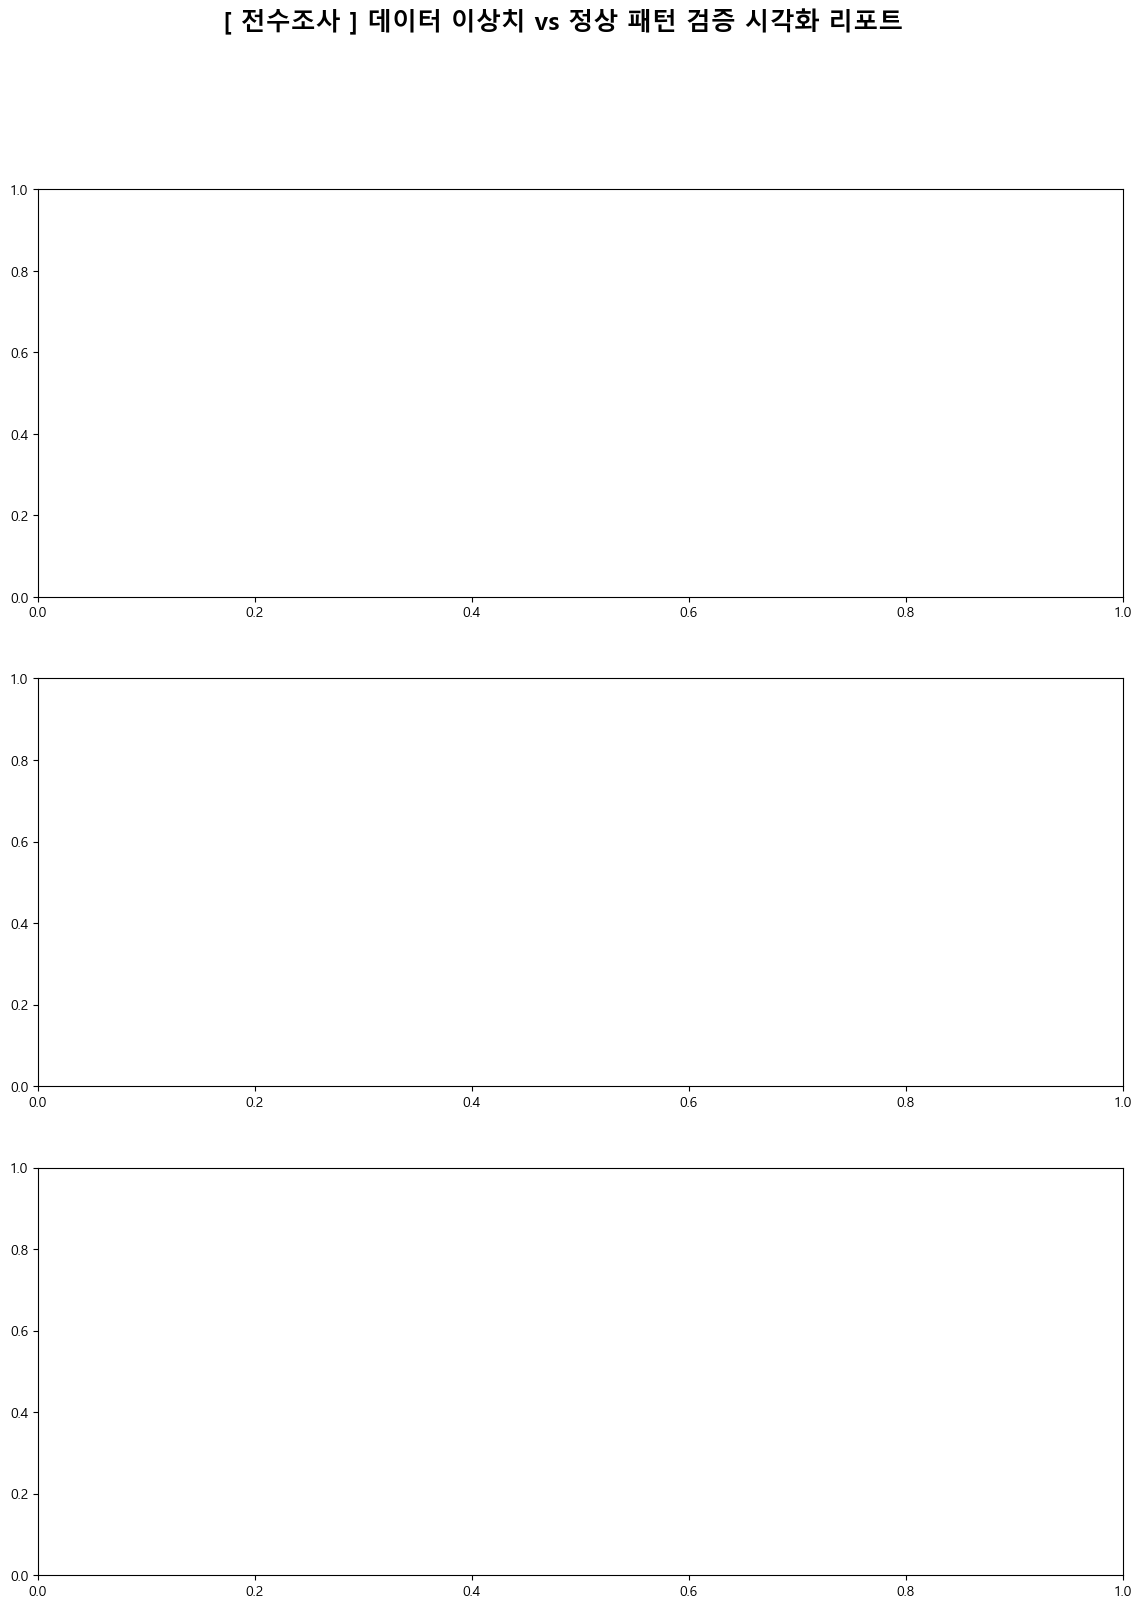

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle("[ 전수조사 ] 데이터 이상치 vs 정상 패턴 검증 시각화 리포트", fontsize=18, fontweight='bold')

# ------------------------------------------------------------------
# 1. VRATE(환기율)의 시계열 플롯: 특정 기간의 발산인가?
# ------------------------------------------------------------------
# 이미 안전하게 검증된 train_set 내부의 컬럼을 다이렉트로 매핑
vrate_col = 'gfs_planetaryBoundaryLayer_0_VRATE'
axes[0].plot(train_set['kst_dtm'], train_set[vrate_col], color='tab:blue', alpha=0.6)
axes[0].axhline(y=50000, color='r', linestyle='--', label='위험 발산 임계치 (50,000)')
axes[0].set_title("1. GFS VRATE(환기율) 전체 기간 트렌드", fontsize=13, fontweight='bold')
axes[0].set_ylabel("VRATE 수치")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------------------------
# 2. NDNLW(순 장파 복사)의 시간대별 박스플롯: 복사 냉각 패턴 검증
# ------------------------------------------------------------------
ndnlw_col = 'gfs_surface_0_NDNLW'
# 주입된 hour 파생 변수 활용
sns.boxplot(data=train_set, x='hour', y=ndnlw_col, ax=axes[1], palette='coolwarm')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1].set_title("2. 24시간 시간대별 NDNLW(순 장파 복사) 분포 (음수 구역 확인)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("하루 시간대 (Hour)")
axes[1].set_ylabel("순 복사 에너지")
axes[1].grid(True, alpha=0.3)

# ------------------------------------------------------------------
# 3. kpx_group_3 라벨의 결측치 타임라인 구간 검증
# ------------------------------------------------------------------
labels_copy = train_labels.copy()
labels_copy['g3_is_null'] = labels_copy['kpx_group_3'].isnull().astype(int)

axes[2].fill_between(labels_copy['kst_dtm'], labels_copy['g3_is_null'], color='tab:red', alpha=0.5, label='결측 구간 (NaN)')
axes[2].set_title("3. 시간 흐름에 따른 kpx_group_3 결측치(NaN) 발생 구간", fontsize=13, fontweight='bold')
axes[2].set_xlabel("날짜 및 시간")
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['정상 측정', '결측치 발생'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# 현재 데이터프레임에 들어있는 진짜 컬럼 목록 중, 문제가 된 단어(VRATE, NDNLW)가 포함된 진짜 이름만 검색
[col for col in train_set.columns if 'VRATE' in col or 'NDNLW' in col]

[]

In [21]:
# 현재 데이터프레임에 살아있는 모든 컬럼명을 글자순으로 정렬해서 출력
sorted(list(train_set.columns))

['day_of_year',
 'forecast_kst_dtm_x',
 'forecast_kst_dtm_y',
 'gfs_absolute_humidity_mean',
 'gfs_air_density_mean',
 'gfs_air_pressure_mean',
 'gfs_ws_cos_mean',
 'gfs_ws_cubed_max',
 'gfs_ws_cubed_mean',
 'gfs_ws_max',
 'gfs_ws_mean',
 'gfs_ws_mean_lag1',
 'gfs_ws_mean_lead1',
 'gfs_ws_rolling_3h',
 'gfs_ws_sin_mean',
 'gfs_ws_squared_max',
 'gfs_ws_squared_mean',
 'gfs_ws_std',
 'hour',
 'hour_cos',
 'hour_sin',
 'kpx_group_1',
 'kpx_group_2',
 'kpx_group_3',
 'kst_dtm',
 'ldaps_absolute_humidity_mean',
 'ldaps_air_density_mean',
 'ldaps_air_pressure_mean',
 'ldaps_ws_cos_mean',
 'ldaps_ws_cubed_max',
 'ldaps_ws_cubed_mean',
 'ldaps_ws_max',
 'ldaps_ws_mean',
 'ldaps_ws_mean_lag1',
 'ldaps_ws_mean_lead1',
 'ldaps_ws_rolling_3h',
 'ldaps_ws_sin_mean',
 'ldaps_ws_squared_max',
 'ldaps_ws_squared_mean',
 'ldaps_ws_std',
 'month',
 'unison_downtime_ratio',
 'vestas_downtime_ratio']